# Overview - ML Classifiers (yes/no weather delay)

- BEST MODEL: HistGradientBoostingClassifier (with airport codes dropped; Ordinal Encoder) -- scroll all the way to bottom 
- Other models tested: SGDClassifier, Logistic Regression -- similar performance; both had less precision, f1-score than HGBClassifier
- Evaluted with classification report, confusion matrix, average precision score, permutation importance

### Loading Data

In [115]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

In [116]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from scipy.spatial import cKDTree

In [117]:
df = pd.read_csv("combined.csv")

# Drop columns that are leakage or not useful for prediction
df = df.drop(columns=["date", "origin_lat", "origin_lon", "dest_lat", "dest_lon"])

# Fill NaN values in weather columns with median
weather_feature_cols = [c for c in df.columns if (c.startswith("origin_") or c.startswith("dest_")) and df[c].dtype != object]
df[weather_feature_cols] = df[weather_feature_cols].fillna(df[weather_feature_cols].median())    

# Encode carrier code
le = LabelEncoder()
df["Carrier Code"] = le.fit_transform(df["Carrier Code"])
carrier_mapping = dict(zip(le.transform(le.classes_), le.classes_))
    
# Encode origin and destination with shared mapping
all_airports = pd.Series(pd.concat([df["origin_code"], df["destination_code"]]).unique())
le.fit(all_airports)
airport_mapping = dict(zip(le.transform(le.classes_), le.classes_))
df["origin_code"] = le.transform(df["origin_code"])
df["destination_code"] = le.transform(df["destination_code"])
    
print("Carrier mapping:", carrier_mapping)
print("Airport mapping:", airport_mapping)

Carrier mapping: {np.int64(0): 'AA', np.int64(1): 'DL', np.int64(2): 'UA', np.int64(3): 'WN'}
Airport mapping: {np.int64(0): 'ABQ', np.int64(1): 'AGS', np.int64(2): 'ALB', np.int64(3): 'AMA', np.int64(4): 'ANC', np.int64(5): 'ATL', np.int64(6): 'ATW', np.int64(7): 'AUS', np.int64(8): 'AVL', np.int64(9): 'AVP', np.int64(10): 'BDL', np.int64(11): 'BFL', np.int64(12): 'BGR', np.int64(13): 'BHM', np.int64(14): 'BIL', np.int64(15): 'BIS', np.int64(16): 'BLI', np.int64(17): 'BNA', np.int64(18): 'BOI', np.int64(19): 'BOS', np.int64(20): 'BQN', np.int64(21): 'BTR', np.int64(22): 'BTV', np.int64(23): 'BUF', np.int64(24): 'BUR', np.int64(25): 'BWI', np.int64(26): 'BZN', np.int64(27): 'CAE', np.int64(28): 'CHA', np.int64(29): 'CHO', np.int64(30): 'CHS', np.int64(31): 'CID', np.int64(32): 'CLE', np.int64(33): 'CLT', np.int64(34): 'CMH', np.int64(35): 'COS', np.int64(36): 'CRP', np.int64(37): 'CVG', np.int64(38): 'DAB', np.int64(39): 'DAL', np.int64(40): 'DAY', np.int64(41): 'DCA', np.int64(42): 'D

### One Hot Encoding

In [95]:
cols = ['Carrier Code', 'destination_code', 'origin_code', 'scheduled_hour', 'month']

In [96]:
def one_hot(df, cols):
    """
    df: pandas DataFrame
    cols: a list of columns to encode 
    return a DataFrame with one-hot encoding
    """
    for each in cols:
        dummies = pd.get_dummies(df[each], prefix=each, drop_first=True, sparse=True) # creates the one-hot encoding cols
        dummies.sparse.to_coo().tocsr()
        df = pd.concat([df, dummies], axis=1)

    return df

cleaned_df = one_hot(df, cols)

### Setting X, y; dropping columns

In [6]:
X = cleaned_df.drop(['Departure delay (Minutes)',
            'Scheduled elapsed time (Minutes)', 'Actual elapsed time (Minutes)',
             'Taxi-Out time (Minutes)', 'day_of_week',
             'weather_delayed', 
            ], axis=1)
y = cleaned_df['weather_delayed'] # 'weather_delayed' for yes/no flight is delayed; 'Departure delay (Minutes)' for predicting minutes

X = X.astype(np.float32)




### Train-test split

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### Removing Nan values

In [8]:
def clean(df):
    # Drop any remaining NaN rows
    return df.dropna()

X_train = clean(X_train)
X_test = clean(X_test)
y_train = clean(y_train)
y_test = clean(y_test)

# SGDClassifier

## Model 1

In [9]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

clf = make_pipeline(
    StandardScaler(with_mean=False),
    SGDClassifier(
        loss="log_loss", # better than hinge
        penalty="l2",
        alpha=1e-4, #tested, optimal value
        max_iter=2000, #2000
        tol=1e-4,
        class_weight="balanced",
        learning_rate="optimal"
    )
)

In [10]:
clf.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler(with_mean=False)),
                ('sgdclassifier',
                 SGDClassifier(class_weight='balanced', loss='log_loss',
                               max_iter=2000, tol=0.0001))])

In [11]:
y_pred = clf.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.8851095260363032

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.89      0.94    785353
           1       0.06      0.71      0.11      8020

    accuracy                           0.89    793373
   macro avg       0.53      0.80      0.52    793373
weighted avg       0.99      0.89      0.93    793373



In [34]:
# adjusted threshold to up precision and f1 (w/ consequence of lowering recall)

y_probs = clf.predict_proba(X_test)[:,1]
y_pred = (y_probs > 0.79).astype(int)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.955647595771472

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.96      0.98    785353
           1       0.10      0.44      0.17      8020

    accuracy                           0.96    793373
   macro avg       0.55      0.70      0.57    793373
weighted avg       0.99      0.96      0.97    793373



In [35]:
from sklearn.metrics import average_precision_score

average_precision_score(y_test, probs)

# 0.09 avg precision score 

np.float64(0.09493934910589068)

# SGD Classifier

## Model 2

In [10]:
scaler = StandardScaler()

scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
clf = SGDClassifier(
    loss="log_loss",        
    penalty="elasticnet",
    l1_ratio=0.15,
    alpha=1e-4,
    max_iter=2000,
    tol=1e-4,
    learning_rate="adaptive",
    eta0=0.01,
    class_weight='balanced',
    early_stopping=True,
)

In [39]:
clf.fit(X_train_scaled, y_train)

SGDClassifier(class_weight='balanced', early_stopping=True, eta0=0.01,
              learning_rate='adaptive', loss='log_loss', max_iter=2000,
              penalty='elasticnet', tol=0.0001)

In [40]:
y_pred = clf.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.8388815853324981

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.84      0.91    785353
           1       0.05      0.79      0.09      8020

    accuracy                           0.84    793373
   macro avg       0.52      0.82      0.50    793373
weighted avg       0.99      0.84      0.90    793373



In [48]:
# performs better than Model 1 once thresholds are adjusted

y_probs = clf.predict_proba(X_test_scaled)[:,1]
y_pred = (y_probs > 0.82).astype(int)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.948750461636582

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.95      0.97    785353
           1       0.10      0.48      0.16      8020

    accuracy                           0.95    793373
   macro avg       0.54      0.72      0.57    793373
weighted avg       0.99      0.95      0.97    793373



# Logistic Regression Model

### Similar performance to SGDClassifier Models

In [9]:
from sklearn.linear_model import LogisticRegression

In [10]:
scaler = StandardScaler()

scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
log_reg = LogisticRegression(
    solver="saga", 
    penalty="l2",
    C=1,
    max_iter=750, 
    class_weight="balanced",
    tol=1e-3,
    verbose=1,
    n_jobs=-1,
    )


In [21]:
log_reg.fit(X_train_scaled, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


Epoch 1, change: 1
Epoch 2, change: 0.20680992
Epoch 3, change: 0.17144275
Epoch 4, change: 0.136222
Epoch 1, change: 1
Epoch 2, change: 0.18468386
Epoch 5, change: 0.13337968
Epoch 6, change: 0.14232564
Epoch 3, change: 0.065751992
Epoch 7, change: 0.12354289
Epoch 4, change: 0.17445855
Epoch 8, change: 0.15271908
Epoch 5, change: 0.14583158
Epoch 9, change: 0.17008337
Epoch 6, change: 0.036980741
Epoch 10, change: 0.17363
Epoch 7, change: 0.1635136
Epoch 11, change: 0.12966099
Epoch 8, change: 0.17091259
Epoch 12, change: 0.1268501
Epoch 9, change: 0.15705812
Epoch 13, change: 0.17621423
Epoch 10, change: 0.1270054
Epoch 14, change: 0.15503226
Epoch 11, change: 0.18311189
Epoch 15, change: 0.1492376
Epoch 12, change: 0.1373589
Epoch 16, change: 0.1843735
Epoch 13, change: 0.18261731
Epoch 17, change: 0.15268078
Epoch 14, change: 0.12807857
Epoch 18, change: 0.14658403
Epoch 15, change: 0.044544846
Epoch 19, change: 0.14025025
Epoch 16, change: 0.17024735
Epoch 20, change: 0.13809933


LogisticRegression(C=1, class_weight='balanced', max_iter=750, n_jobs=-1,
                   solver='saga', tol=0.001, verbose=1)

In [37]:
from sklearn.metrics import precision_score

y_pred = log_reg.predict(X_test_scaled)

accuracy = log_reg.score(X_test_scaled, y_test)
print(f"Accuracy: {accuracy}")


from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

Accuracy: 0.8289820803077493
              precision    recall  f1-score   support

           0       1.00      0.83      0.91    785447
           1       0.05      0.81      0.09      7926

    accuracy                           0.83    793373
   macro avg       0.52      0.82      0.50    793373
weighted avg       0.99      0.83      0.90    793373



In [39]:
y_probs = log_reg.predict_proba(X_test_scaled)[:,1]
y_pred = (y_probs > 0.85).astype(int)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9512789066429032

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.96      0.97    785447
           1       0.10      0.48      0.16      7926

    accuracy                           0.95    793373
   macro avg       0.55      0.72      0.57    793373
weighted avg       0.99      0.95      0.97    793373



In [40]:
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[750949  34498]
 [  4156   3770]]


# HistGradientBoostingClassifier

## Model 1 (Testing w/ 200 iters)

In [41]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    max_depth=8,
    l2_regularization=1.0,
    early_stopping=True,
    scoring="average_precision"
)

hgb.fit(X_train, y_train)

HistGradientBoostingClassifier(early_stopping=True, l2_regularization=1.0,
                               learning_rate=0.05, max_depth=8, max_iter=200,
                               scoring='average_precision')

In [52]:
accuracy = hgb.score(X_test, y_test)
print(f"Accuracy: {accuracy}")

y_pred = hgb.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

Accuracy: 0.9901294851223825
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    785447
           1       0.59      0.04      0.08      7926

    accuracy                           0.99    793373
   macro avg       0.79      0.52      0.54    793373
weighted avg       0.99      0.99      0.99    793373



In [61]:
from sklearn.metrics import classification_report

probs = hgb.predict_proba(X_test)[:,1]

y_pred = (probs > 0.10).astype(int)

print(classification_report(y_test, y_pred))

# Much better precision and f1 score than other models

              precision    recall  f1-score   support

           0       0.99      0.99      0.99    785447
           1       0.26      0.50      0.34      7926

    accuracy                           0.98    793373
   macro avg       0.63      0.74      0.67    793373
weighted avg       0.99      0.98      0.98    793373



In [56]:
from sklearn.metrics import average_precision_score

print(average_precision_score(y_test, probs))

# Much higher than log reg or sgd classifier (those were around 0.09)

0.27534684080020533


In [62]:
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[774173  11274]
 [  3952   3974]]


In [63]:
hgb.n_iter_

200

## Model 2 (1000 iters)

In [64]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    max_iter=1000,
    learning_rate=0.05,
    max_depth=10,
    l2_regularization=1.0,
    early_stopping=True,
    scoring="average_precision"
)

hgb.fit(X_train, y_train)

HistGradientBoostingClassifier(early_stopping=True, l2_regularization=1.0,
                               learning_rate=0.05, max_depth=10, max_iter=1000,
                               scoring='average_precision')

In [65]:
accuracy = hgb.score(X_test, y_test)
print(f"Accuracy: {accuracy}")

y_pred = hgb.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

Accuracy: 0.9902819985051168
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    785447
           1       0.65      0.06      0.11      7926

    accuracy                           0.99    793373
   macro avg       0.82      0.53      0.55    793373
weighted avg       0.99      0.99      0.99    793373



In [66]:
from sklearn.metrics import classification_report

probs = hgb.predict_proba(X_test)[:,1]

y_pred = (probs > 0.10).astype(int)

print(classification_report(y_test, y_pred))

# Overall best precision, recall, and f1-score

              precision    recall  f1-score   support

           0       1.00      0.99      0.99    785447
           1       0.28      0.56      0.37      7926

    accuracy                           0.98    793373
   macro avg       0.64      0.77      0.68    793373
weighted avg       0.99      0.98      0.98    793373



In [67]:
from sklearn.metrics import average_precision_score

print(average_precision_score(y_test, probs))

# much higher average precision score (0.325) than other classifiers

0.32509443824847256


In [69]:
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[773791  11656]
 [  3467   4459]]


In [68]:
hgb.n_iter_

580

### Ensuring not overfitting

[0.01       0.11743943 0.14716755 0.15212178 0.15611503 0.15481567
 0.16063316 0.15764025 0.15893182 0.16287633 0.16603508 0.16592714
 0.16893348 0.16954266 0.16956257 0.16998489 0.17152543 0.17226922
 0.17266021 0.17396132 0.17692054 0.17746964 0.17881117 0.18040484
 0.18067301 0.18329986 0.18323578 0.18517225 0.18541071 0.18605774
 0.1867763  0.1869853  0.18835484 0.18918604 0.18979987 0.19101985
 0.19143749 0.19271184 0.19317434 0.19370301 0.19349376 0.19377681
 0.19513846 0.19623598 0.19712585 0.19870991 0.19946276 0.20100039
 0.2013088  0.20098787 0.20224153 0.19993527 0.20199671 0.20287697
 0.20240905 0.20274926 0.20323765 0.20521857 0.20645852 0.20626494
 0.20758053 0.20818674 0.20951392 0.21022147 0.21162357 0.21253962
 0.2180295  0.21905325 0.22021493 0.22186379 0.22357831 0.22425715
 0.22388765 0.22445336 0.22530164 0.22573132 0.2261983  0.22667362
 0.22919926 0.22906674 0.22918481 0.22956702 0.23111743 0.23204452
 0.23242224 0.23378377 0.23460811 0.2356675  0.23564934 0.2355

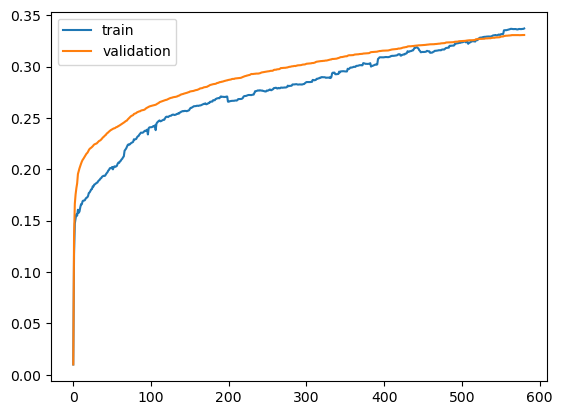

In [76]:
print(hgb.train_score_)
print(hgb.validation_score_)

plt.plot(hgb.train_score_, label="train")
plt.plot(hgb.validation_score_, label="validation")
plt.legend()
plt.show()

# not overfitting

### Using Shap to evaluate feature importance

100%|===================| 793222/793373 [72:03<00:00]        

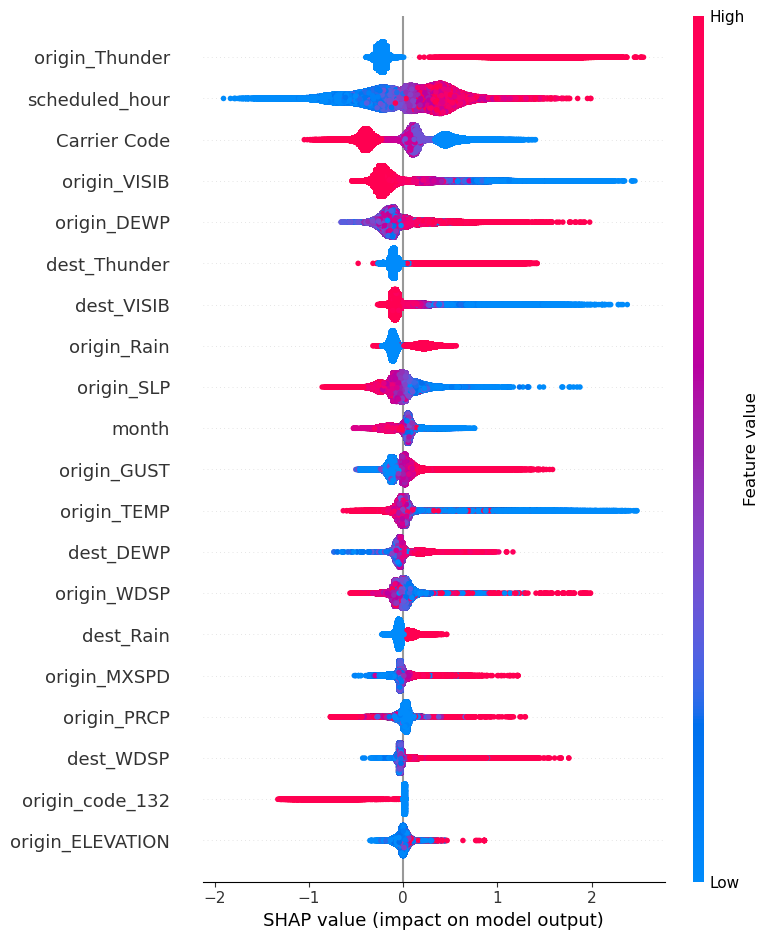

In [82]:
import shap

explainer = shap.Explainer(hgb, X_train)
shap_values = explainer(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

# Shows which features are most important including which direction values increase or decrease chance of flight delay

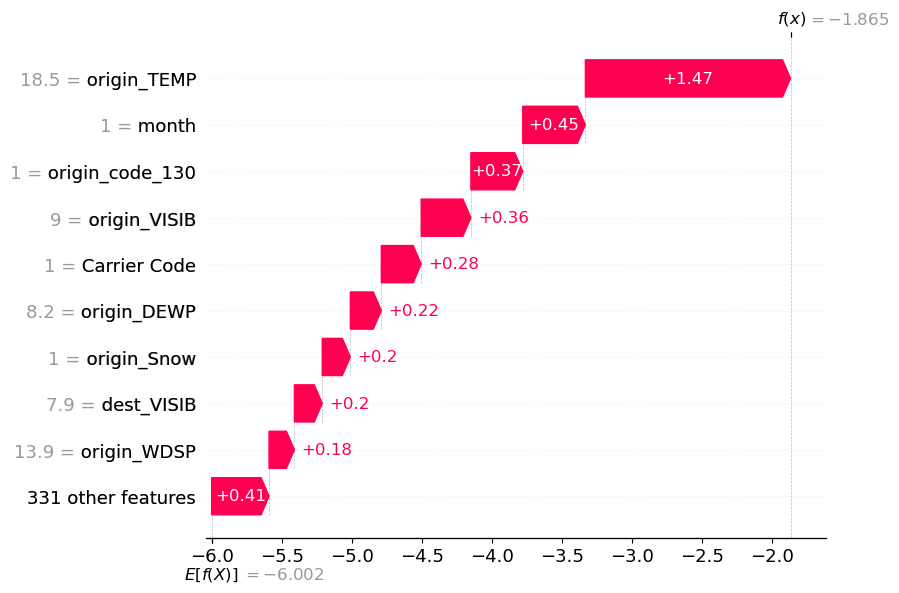

In [86]:
shap.plots.waterfall(shap_values[0])

# for one flight, shows what values increase chance of flight delay

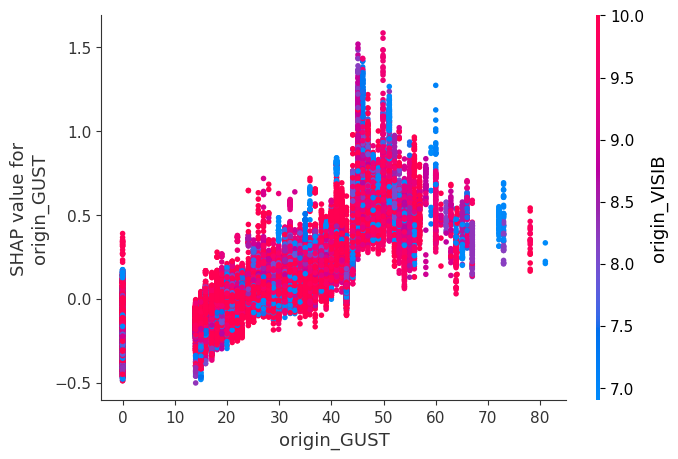

In [91]:
shap.dependence_plot(
    "origin_GUST",
    shap_values.values,
    X_test
)

# as gust increases, more risk of flight delay

# HistGradientBoostingClassifier without Airports

### One Hot Encoding

In [118]:
cols = ['scheduled_hour', 'month', 'Carrier Code']

In [119]:
def one_hot(df, cols):
    """
    df: pandas DataFrame
    cols: a list of columns to encode 
    return a DataFrame with one-hot encoding
    """
    for each in cols:
        dummies = pd.get_dummies(df[each], prefix=each, drop_first=True, sparse=True) # creates the one-hot encoding cols
        dummies.sparse.to_coo().tocsr()
        df = pd.concat([df, dummies], axis=1)

    return df

cleaned_df = one_hot(df, cols)

### Setting X, y; dropping columns (*now including airport codes)

In [120]:
X = cleaned_df.drop(['Departure delay (Minutes)',
            'Scheduled elapsed time (Minutes)', 'Actual elapsed time (Minutes)',
             'Taxi-Out time (Minutes)', 'day_of_week',
             'weather_delayed', 'destination_code', 'origin_code'
            ], axis=1)
y = cleaned_df['weather_delayed'] # 'weather_delayed' for yes/no flight is delayed; 'Departure delay (Minutes)' for predicting minutes

X = X.astype(np.float32)



### Train-test split

In [121]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### Dropping Nan values

In [122]:
def clean(df):
    # Drop any remaining NaN rows
    return df.dropna()

X_train = clean(X_train)
X_test = clean(X_test)
y_train = clean(y_train)
y_test = clean(y_test)

### Fitting Model

In [123]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    max_iter=1000,
    learning_rate=0.05,
    max_depth=10,
    l2_regularization=1.0,
    early_stopping=True,
    scoring="average_precision"
)

hgb.fit(X_train, y_train)

HistGradientBoostingClassifier(early_stopping=True, l2_regularization=1.0,
                               learning_rate=0.05, max_depth=10, max_iter=1000,
                               scoring='average_precision')

### Evaluation

In [124]:
accuracy = hgb.score(X_test, y_test)
print(f"Accuracy: {accuracy}")

y_pred = hgb.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

Accuracy: 0.9904332514466714
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    785473
           1       0.62      0.10      0.18      7900

    accuracy                           0.99    793373
   macro avg       0.80      0.55      0.59    793373
weighted avg       0.99      0.99      0.99    793373



In [141]:
# adjusting precision threshold

from sklearn.metrics import classification_report

probs = hgb.predict_proba(X_test)[:,1]

y_pred = (probs > 0.10).astype(int)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.99      0.99    785473
           1       0.29      0.59      0.39      7900

    accuracy                           0.98    793373
   macro avg       0.64      0.79      0.69    793373
weighted avg       0.99      0.98      0.98    793373



In [150]:

from sklearn.metrics import classification_report

probs = hgb.predict_proba(X_test)[:,1]

y_pred = (probs > 0.12).astype(int)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99    785473
           1       0.32      0.55      0.40      7900

    accuracy                           0.98    793373
   macro avg       0.66      0.77      0.70    793373
weighted avg       0.99      0.98      0.99    793373



In [151]:
from sklearn.metrics import average_precision_score

print(average_precision_score(y_test, probs))


0.3467106763975293


In [142]:
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)


Confusion Matrix:
[[773829  11644]
 [  3236   4664]]


In [161]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    hgb,
    X_test,
    y_test,
    n_repeats=10,
    scoring="average_precision",
    n_jobs=-1
)

feature_importances = pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False)

print(feature_importances)

scheduled_hour         0.174042
origin_Thunder         0.160500
origin_DEWP            0.120082
origin_VISIB           0.105597
Carrier Code           0.102906
                         ...   
month_12.0             0.000000
dest_Tornado           0.000000
scheduled_hour_23.0    0.000000
origin_Tornado         0.000000
Carrier Code_3         0.000000
Length: 69, dtype: float64


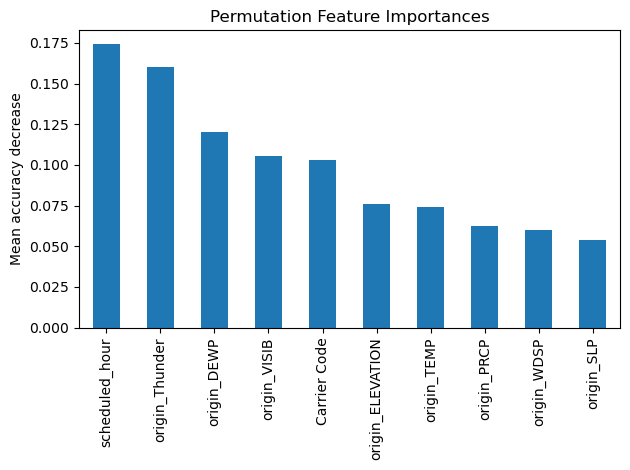

In [162]:
fig, ax = plt.subplots()
feature_importances[:10].plot.bar(ax=ax)
ax.set_title("Permutation Feature Importances")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()

# **BEST MODEL**

# HistGradientBoostingClassifier (OrdinalEncoder)

In [175]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
import pandas as pd

### Setting X, y; dropping cols

In [176]:
X = df.drop(['Departure delay (Minutes)',
            'Scheduled elapsed time (Minutes)', 'Actual elapsed time (Minutes)',
             'Taxi-Out time (Minutes)', 'day_of_week',
             'weather_delayed', 'destination_code', 'origin_code'
            ], axis=1)
y = df['weather_delayed'] # 'weather_delayed' for yes/no flight is delayed; 'Departure delay (Minutes)' for predicting minutes

X = X.astype(np.float32)

### Test-train split

In [177]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### Pipeline w/ Ordinal Encoder

In [178]:
preprocessor = make_column_transformer(
    (OrdinalEncoder(), ['scheduled_hour', 'month', 'Carrier Code']), 
    remainder='passthrough'
)

hgb = make_pipeline(
    preprocessor,
    HistGradientBoostingClassifier(
        max_iter=1000,
        learning_rate=0.05,
        max_depth=10,
        l2_regularization=1.0, # stops overfitting
        early_stopping=True,
        scoring="average_precision") 
)

hgb.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(),
                                                  ['scheduled_hour', 'month',
                                                   'Carrier Code'])])),
                ('histgradientboostingclassifier',
                 HistGradientBoostingClassifier(early_stopping=True,
                                                l2_regularization=1.0,
                                                learning_rate=0.05,
                                                max_depth=10, max_iter=1000,
                                                scoring='average_precision'))])

### Evaluation

In [179]:
accuracy = hgb.score(X_test, y_test)
print(f"Accuracy: {accuracy}")

y_pred = hgb.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

Accuracy: 0.990231580857932
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    785323
           1       0.63      0.09      0.16      8050

    accuracy                           0.99    793373
   macro avg       0.81      0.55      0.58    793373
weighted avg       0.99      0.99      0.99    793373



In [188]:
from sklearn.metrics import classification_report

probs = hgb.predict_proba(X_test)[:,1]

y_pred = (probs > 0.16).astype(int)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99    785323
           1       0.38      0.47      0.42      8050

    accuracy                           0.99    793373
   macro avg       0.69      0.73      0.71    793373
weighted avg       0.99      0.99      0.99    793373



In [181]:
from sklearn.metrics import average_precision_score

print(average_precision_score(y_test, probs))
# highest avg precision score yet

0.35305607133297434


In [189]:
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[779059   6264]
 [  4233   3817]]


In [190]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    hgb,
    X_test,
    y_test,
    n_repeats=10,
    scoring="average_precision",
    n_jobs=-1
)

feature_importances = pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False)

print(feature_importances)

scheduled_hour      0.186134
origin_Thunder      0.154069
origin_DEWP         0.122801
origin_VISIB        0.107973
Carrier Code        0.105447
origin_ELEVATION    0.084743
origin_TEMP         0.065998
origin_WDSP         0.061825
month               0.057718
origin_PRCP         0.054220
origin_SLP          0.053179
origin_MXSPD        0.038211
origin_GUST         0.037228
origin_Rain         0.021941
origin_Snow         0.009974
dest_DEWP           0.007378
dest_Thunder        0.007114
dest_ELEVATION      0.006422
origin_SNDP         0.005357
dest_VISIB          0.005235
dest_TEMP           0.004341
origin_Fog          0.004318
dest_PRCP           0.003307
dest_WDSP           0.003244
dest_SLP            0.003113
dest_MXSPD          0.002461
dest_Rain           0.002299
origin_Hail         0.002102
dest_GUST           0.001928
dest_Fog            0.000606
dest_Hail           0.000184
origin_Tornado      0.000000
dest_Tornado       -0.000002
dest_SNDP          -0.000021
dest_Snow     

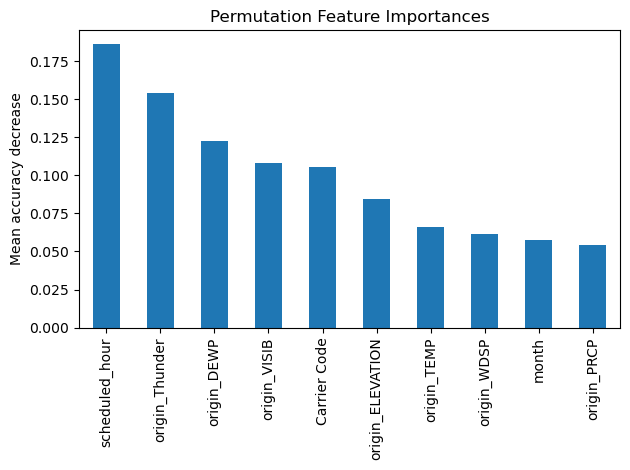

In [191]:
fig, ax = plt.subplots()
feature_importances[:10].plot.bar(ax=ax)
ax.set_title("Permutation Feature Importances")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()